In [1]:
!pip install -q scikit-learn

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk, concatenate_datasets, Audio
import glob
from datasets import disable_caching
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
)

from torchvision.models import resnet18

from google.colab import drive

drive.mount('/content/drive')

NUM_CLASSES = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings

/content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings


## Load Data and DataLoader (dev and test set)

In [4]:
disable_caching()

# loading data

chunk_paths = sorted(glob.glob("speaker_chunks/chunk_*"))

chunks = []
for path in chunk_paths:
    ds = load_from_disk(path)
    ds = ds.cast_column("audio_path", Audio(sampling_rate=16000))
    chunks.append(ds)

full_dataset = concatenate_datasets(chunks)

In [5]:
split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]

temp = split["test"].train_test_split(test_size=0.5, seed=42)
dev_dataset = temp["train"]
test_dataset = temp["test"]

In [6]:
import sys
sys.path.insert(0, "/content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings")

# Force reload the module if it was previously imported from the wrong location
if 'dataset' in sys.modules:
    del sys.modules['dataset']

from dataset import Dataset_Builder

config = {"shortest_duration": 4.0}
dev_builder = Dataset_Builder(dev_dataset, **config)
dev_builder.filter()
dev_builder.preprocess()

test_builder = Dataset_Builder(test_dataset, **config)
test_builder.filter()
test_builder.preprocess()

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2402 [00:00<?, ? examples/s]

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2407 [00:00<?, ? examples/s]

In [7]:
dev_dataset = dev_builder.get_dataset()
test_dataset = test_builder.get_dataset()

In [8]:
def collate_fn(batch):
    log_mels = torch.stack([b["log_mel"] for b in batch])
    labels = torch.tensor([b["label"] for b in batch])
    return (log_mels, labels)

In [9]:
dev_loader = DataLoader(
    dev_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

## Functions for Build Model, Load checkpoint, and Evaluation

In [10]:
def load_model_from_checkpoint(checkpoint_path, num_classes, device):
    model = resnet18(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint)

    model.eval()

    return model

In [11]:
def evaluate(model, dataloader, device):

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for indx, (log_mels, labels) in tqdm(enumerate(dev_loader), total=len(dev_loader)):

            log_mels = log_mels.to(device)
            labels = labels.to(device)

            logits = model(log_mels)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)

    return all_labels, all_preds, all_probs

In [12]:
def compute_metrics(all_labels, all_preds):

    acc = accuracy_score(all_labels, all_preds)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    p_micro, r_micro, f1_micro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="micro",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": p_macro,
        "macro_recall": r_macro,
        "macro_f1": f1_macro,
        "micro_precision": p_micro,
        "micro_recall": r_micro,
        "micro_f1": f1_micro,
    }

In [13]:
def compute_roc(all_labels, all_probs, num_classes):

    y_true = label_binarize(
        all_labels,
        classes=np.arange(num_classes)
    )

    fpr = {}
    tpr = {}
    roc_auc = {}

    # Per-class ROC
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(
            y_true[:, i],
            all_probs[:, i]
        )

        roc_auc[i] = auc(
            fpr[i],
            tpr[i]
        )

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true.ravel(),
        all_probs.ravel()
    )

    roc_auc["micro"] = auc(
        fpr["micro"],
        tpr["micro"]
    )

    # Macro AUC
    roc_auc["macro"] = np.mean(
        [roc_auc[i] for i in range(num_classes)]
    )

    return fpr, tpr, roc_auc

In [14]:
def plot_micro_roc(fpr, tpr, roc_auc, name):

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        linewidth=2,
        label=f"Micro ROC (AUC={roc_auc['micro']:.3f})"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {name}")

    plt.legend()

    plt.show()

In [31]:
def plot_per_class_roc(fpr, tpr, roc_auc, num_classes):
  fig, axes = plt.subplots(5, 10, figsize=(20, 10))
  axes = axes.ravel()

  for i in range(num_classes):
      ax = axes[i]

      ax.plot(fpr[i], tpr[i], linewidth=1.2)

      ax.set_title(f"S{i} AUC={roc_auc[i]:.2f}", fontsize=7)

      ax.set_xlim(0, 0.2)
      ax.set_ylim(0.8, 1.0)

      ax.set_xticks([])
      ax.set_yticks([])

  plt.tight_layout()
  plt.show()

## Accuracy Evaluation (for dev set)

In [16]:
checkpoint_path = "speaker_chunks/best_speaker_resnet.pth"

epoch_6_model = load_model_from_checkpoint(checkpoint_path, NUM_CLASSES, DEVICE)
epoch6_labels, epoch6_preds, epoch6_probs = evaluate(epoch_6_model, dev_loader, DEVICE)
epoch6_metrics = compute_metrics(epoch6_labels, epoch6_preds)

epoch3_checkpoint_path = "speaker_chunks/resnet_3epoch/resnet_epoch_3.pth"
epoch3_model = load_model_from_checkpoint(epoch3_checkpoint_path, NUM_CLASSES, DEVICE)
epoch3_labels, epoch3_preds, epoch3_probs = evaluate(epoch3_model, dev_loader, DEVICE)
epoch3_metrics = compute_metrics(epoch3_labels, epoch3_preds)

100%|██████████| 76/76 [04:09<00:00,  3.28s/it]


## Confusion matrix

In [22]:
print(f"Epoch 6 Metrics: {epoch6_metrics}")
print(f"Epoch 3 Metrics: {epoch3_metrics}")

Epoch 6 Metrics: {'accuracy': 0.9504579517069109, 'macro_precision': 0.9511734477072494, 'macro_recall': 0.9513979667448976, 'macro_f1': 0.9505597456463707, 'micro_precision': 0.9504579517069109, 'micro_recall': 0.9504579517069109, 'micro_f1': 0.9504579517069109}
Epoch 3 Metrics: {'accuracy': 0.9267277268942548, 'macro_precision': 0.927712988687651, 'macro_recall': 0.9273375343642304, 'macro_f1': 0.9263518366188515, 'micro_precision': 0.9267277268942548, 'micro_recall': 0.9267277268942548, 'micro_f1': 0.9267277268942548}


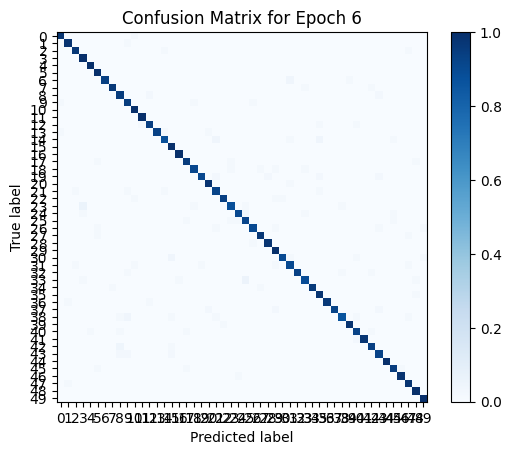

In [17]:
cm = confusion_matrix(epoch6_labels, epoch6_preds, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", include_values=False, colorbar=True)
plt.title("Confusion Matrix for Epoch 6")
plt.show()

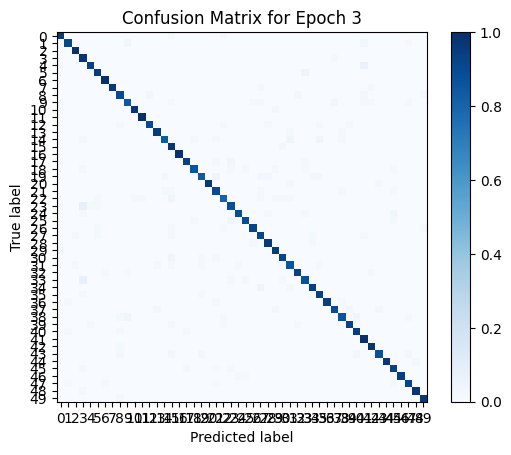

In [18]:
epoch3_cm = confusion_matrix(epoch3_labels, epoch3_preds, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=epoch3_cm)
disp.plot(cmap="Blues", include_values=False, colorbar=True)
plt.title("Confusion Matrix for Epoch 3")
plt.show()

In [19]:
report = classification_report(
    epoch6_labels,
    epoch6_preds,
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report).T
report_df = report_df.iloc[:-3]

report_df

,precision,recall,f1-score,support
0,0.954545,0.976744,0.965517,43.0
1,0.964286,0.981818,0.972973,55.0
2,0.967213,0.967213,0.967213,61.0
3,0.900000,1.000000,0.947368,45.0
4,0.977778,1.000000,0.988764,44.0
5,0.909091,1.000000,0.952381,40.0
6,1.000000,0.936170,0.967033,47.0
7,0.980392,0.961538,0.970874,52.0
8,0.878049,0.947368,0.911392,38.0
9,0.903226,0.949153,0.925620,59.0


In [20]:
epoch3_report = classification_report(
    epoch3_labels,
    epoch3_preds,
    output_dict=True,
    digits=4
)

epoch3_report_df = pd.DataFrame(epoch3_report).T
epoch3_report_df = epoch3_report_df.iloc[:-3]

epoch3_report_df

,precision,recall,f1-score,support
0,0.931818,0.953488,0.942529,43.0
1,0.943396,0.909091,0.925926,55.0
2,0.968254,1.000000,0.983871,61.0
3,0.758621,0.977778,0.854369,45.0
4,0.953488,0.931818,0.942529,44.0
5,0.904762,0.950000,0.926829,40.0
6,0.959184,1.000000,0.979167,47.0
7,1.000000,0.961538,0.980392,52.0
8,0.850000,0.894737,0.871795,38.0
9,0.909091,0.847458,0.877193,59.0


## ROC Evaluation

In [23]:
epoch6_fpr, epoch6_tpr, epoch6_auc = compute_roc(epoch6_labels, epoch6_probs, NUM_CLASSES)
epoch3_fpr, epoch3_tpr, epoch3_auc = compute_roc(epoch3_labels, epoch3_probs, NUM_CLASSES)

print(f"Micro-average Epoch 6 ROC AUC: {epoch6_auc['micro']:.3f}")
print(f"Macro-average Epoch 6 ROC AUC: {epoch6_auc['macro']:.3f}")

print(f"Micro-average Epoch 3 ROC AUC: {epoch3_auc['micro']:.3f}")
print(f"Macro-average Epoch 3 ROC AUC: {epoch3_auc['macro']:.3f}")


Micro-average Epoch 6 ROC AUC: 0.999
Macro-average Epoch 6 ROC AUC: 0.999
Micro-average Epoch 3 ROC AUC: 0.999
Macro-average Epoch 3 ROC AUC: 0.999


## Plot out ROC Curve

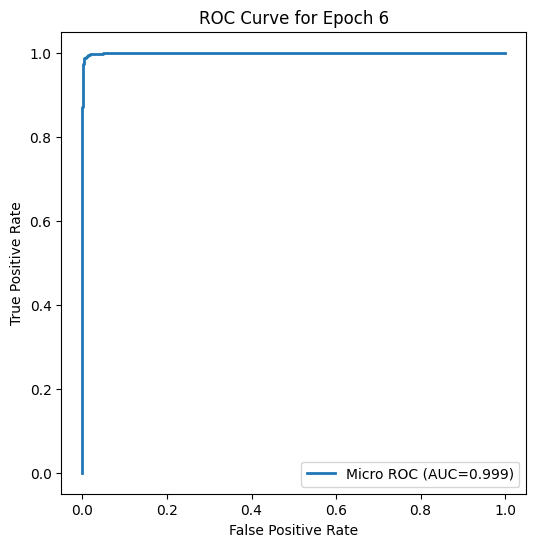

In [24]:
plot_micro_roc(epoch6_fpr, epoch6_tpr, epoch6_auc, "Epoch 6")

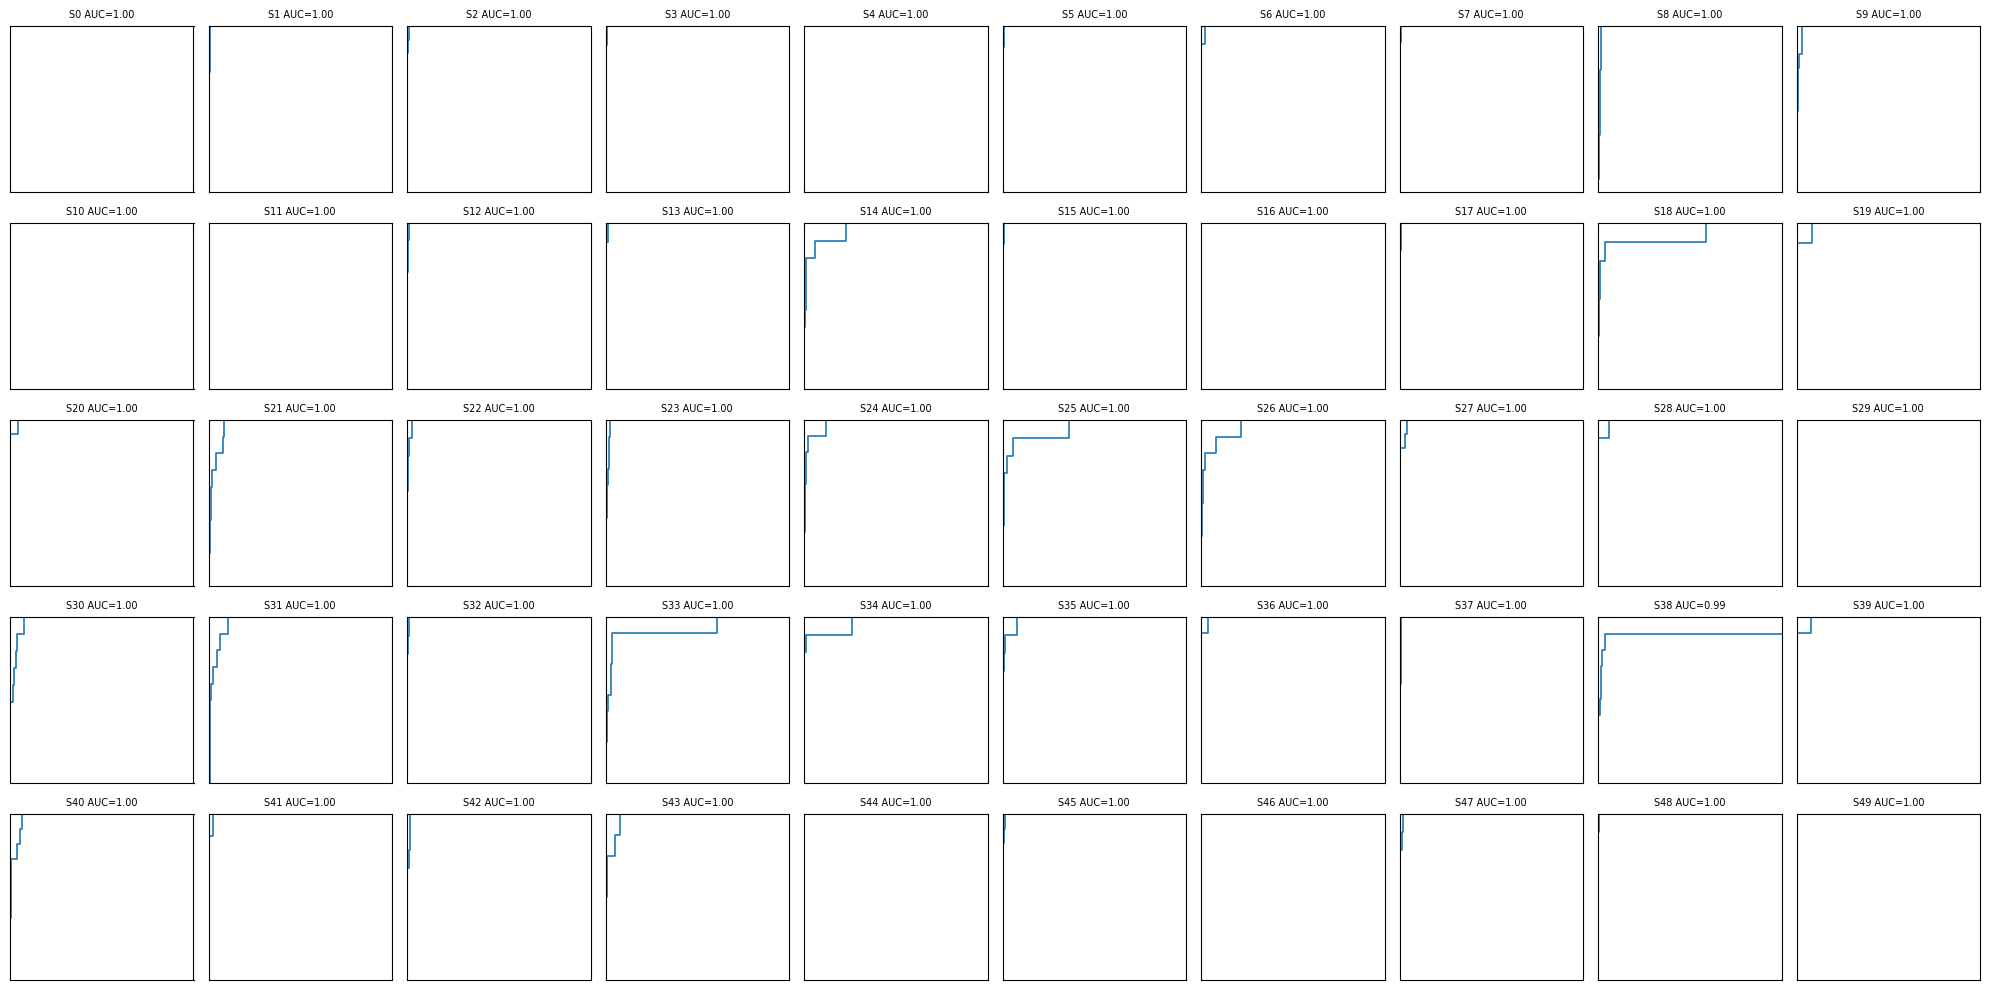

In [34]:
plot_per_class_roc(epoch6_fpr, epoch6_tpr, epoch6_auc, NUM_CLASSES)

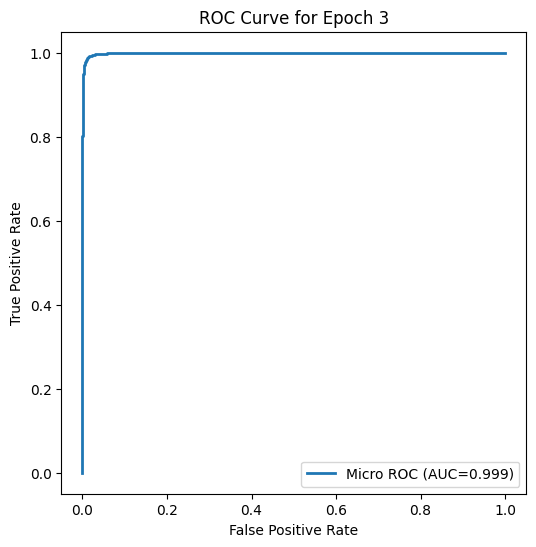

In [26]:
plot_micro_roc(epoch3_fpr, epoch3_tpr, epoch6_auc, "Epoch 3")

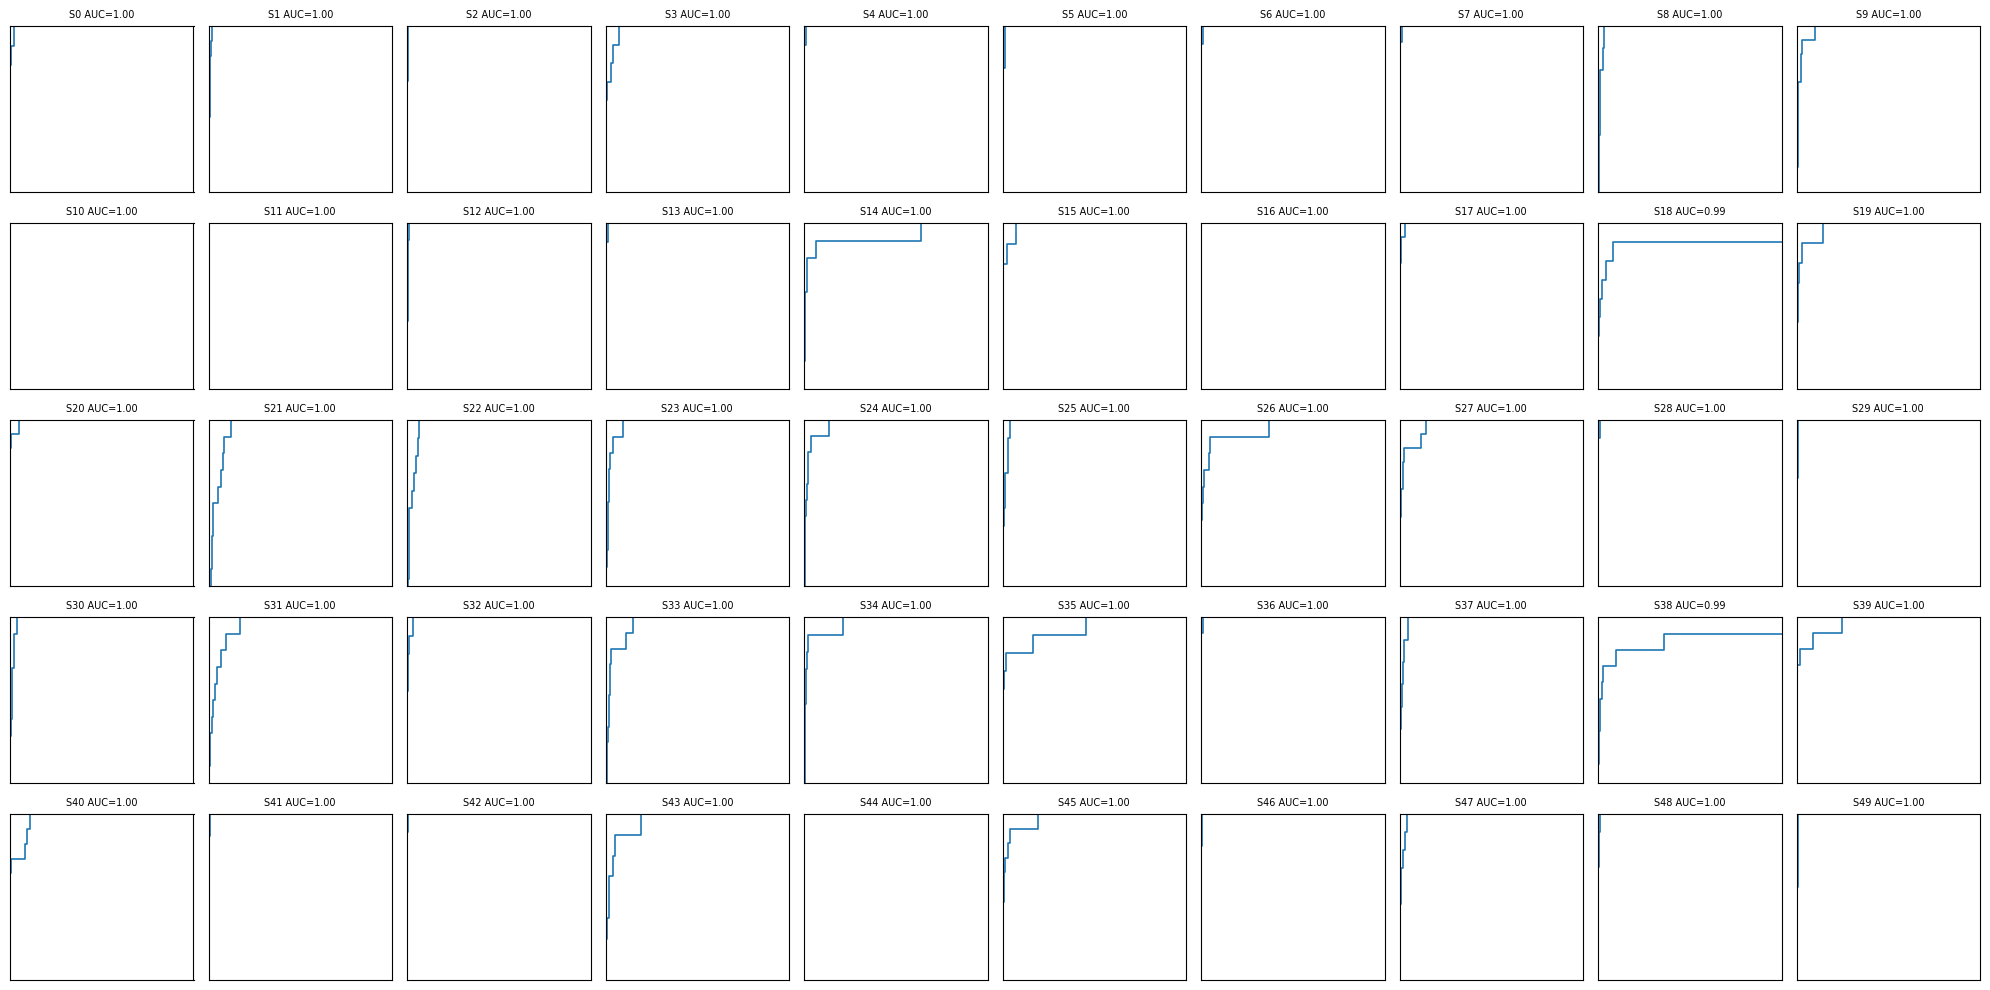

In [35]:
plot_per_class_roc(epoch3_fpr, epoch3_tpr, epoch3_auc, NUM_CLASSES)

## Accuracy and Confusion in 1 - 3 epoch

In [ ]:
checkpoint_paths = [
    "speaker_chunks/resnet_3epoch/resnet_epoch_1.pth",
    "speaker_chunks/resnet_3epoch/resnet_epoch_2.pth",
    "speaker_chunks/resnet_3epoch/resnet_epoch_3.pth",
]

results = []

for ckpt_path in checkpoint_paths:
    model = resnet18(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(DEVICE)

    checkpoint = torch.load(ckpt_path, map_location=DEVICE)

    model.load_state_dict(checkpoint)

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for indx, (log_mels, labels) in tqdm(enumerate(dev_loader), total=len(dev_loader)):
            log_mels = log_mels.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(log_mels)
            preds = torch.argmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    results.append({
        "checkpoint": ckpt_path,
        "accuracy": acc,
        "macro_precision": p_macro,
        "macro_recall": r_macro,
        "macro_f1": f1_macro,
    })

results_df = pd.DataFrame(results)
results_df

100%|██████████| 76/76 [03:51<00:00,  3.05s/it]


,checkpoint,accuracy,macro_precision,macro_recall,macro_f1
0,speaker_chunks/resnet_3epoch/resnet_epoch_1.pth,0.759367,0.772153,0.758928,0.756742
1,speaker_chunks/resnet_3epoch/resnet_epoch_2.pth,0.889675,0.893548,0.889471,0.889065
2,speaker_chunks/resnet_3epoch/resnet_epoch_3.pth,0.925895,0.927357,0.926514,0.925803


## Extract and visualize speaker embeddings

In [ ]:
import umap

In [ ]:
def get_speaker_embedding(model, mel_log, device):

    if not isinstance(mel_log, torch.Tensor):
        mel_log = torch.tensor(mel_log)

    # Ensure the input has a batch dimension (Batch_size, N_Channels, Height, Width)
    if mel_log.ndim == 2:
        # Assuming 2D input is (H, W), make it (1, 1, H, W)
        mel_log = mel_log.unsqueeze(0).unsqueeze(0)
    elif mel_log.ndim == 3:
        # Assuming 3D input is (C, H, W), make it (1, C, H, W)
        mel_log = mel_log.unsqueeze(0)

    mel_log = mel_log.to(device)

    with torch.no_grad():
        #extract embedding = take everything except the last layer
        extractor = torch.nn.Sequential(*list(model.children())[:-1]).to(device)
        speaker_embeddings = extractor(mel_log)
        #normalize along the embedding dimension
        speaker_embeddings = torch.nn.functional.normalize(speaker_embeddings, dim=2)
        #remove the middle dimension and move to CPU
        speaker_embeddings = speaker_embeddings.cpu().numpy()

    return speaker_embeddings

In [ ]:
def visualize_with_umap(embeddings, labels):
    """Generates a UMAP visualization of the embeddings

    Args:
        embeddings (np.array): an array of all speaker embeddings, shape: (N_files, embedding_size)
        labels (np.array): a 1D list with speaker IDs
    """

    #reduce to 2D using UMAP
    umap_model = umap.UMAP(random_state=42)
    emb_tranform = umap_model.fit_transform(embeddings) #shape: (N_files, 2)

    plt.figure(figsize=(10,8))

    #get unique speakers to assign colors
    unique_speakers = np.unique(labels)

    #plot results
    for speaker in unique_speakers:
        mask = (labels == speaker) # to filter out different speakers from data
        plt.scatter(
            emb_tranform[mask, 0], # type: ignore
            emb_tranform[mask, 1], # type: ignore
            label = speaker,
            s=15
            )

    plt.title("Speaker Embeddings mapped with UMAP", fontsize = 24)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
all_embs = []
all_ids = []

for elem in test_dataset:
    #get the log_mel
    log_mel = elem["log_mel"]
    emb = get_speaker_embedding(model, log_mel, DEVICE)
    all_embs.append(emb)

    #extract the corresponding id/label
    id = elem["label"]
    all_ids.append(id)

all_embeddings = np.vstack(all_embs)

In [ ]:
all_embeddings = np.squeeze(all_embeddings)

(2407, 512)

### Visualizing all data points with UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


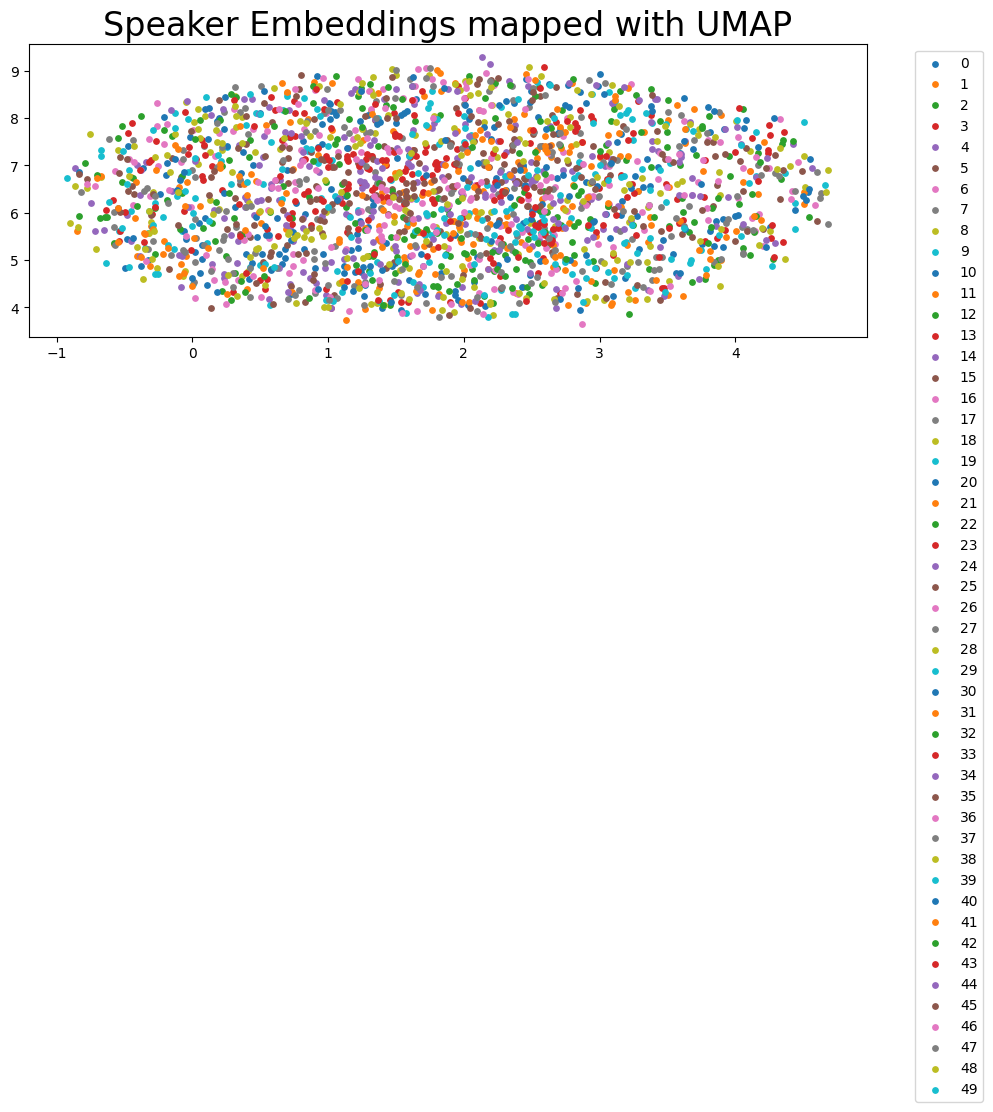

In [ ]:
visualize_with_umap(all_embeddings, all_ids)

### Visualizing first 100 data points with UMAP:

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


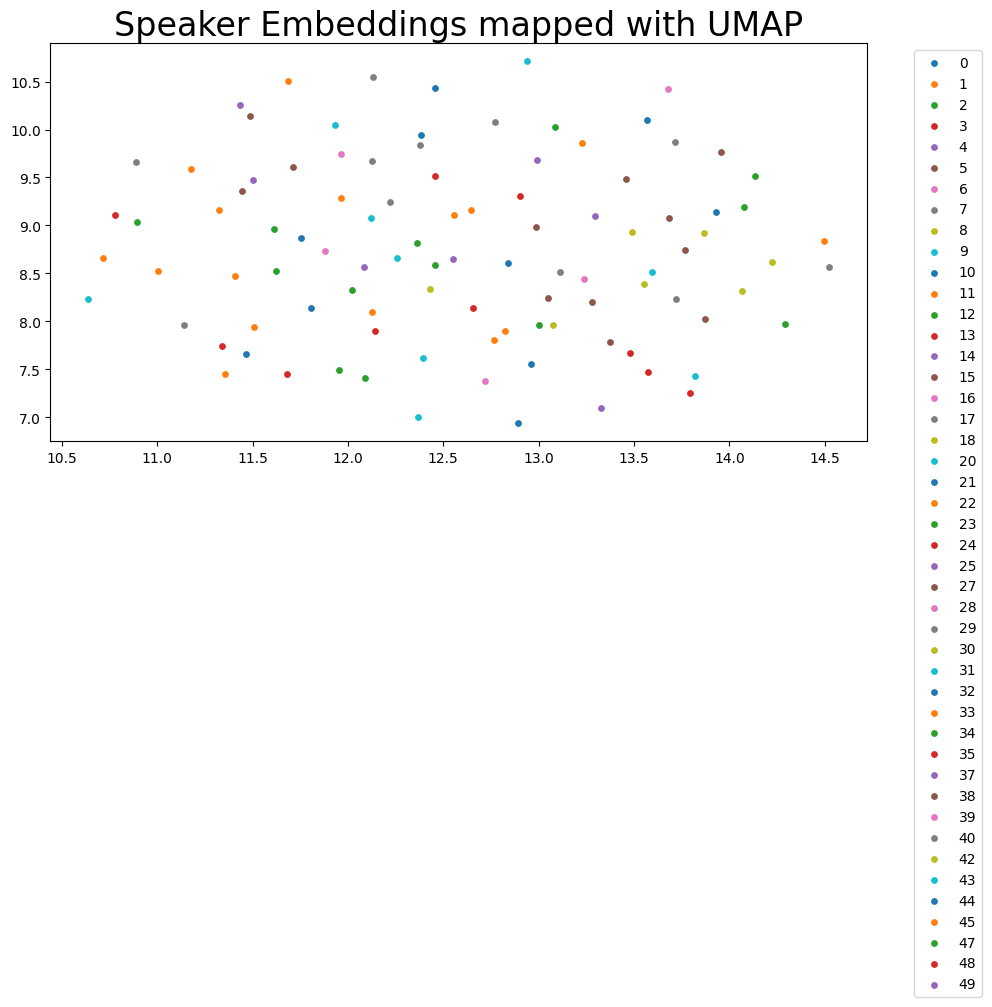

In [ ]:
visualize_with_umap(all_embeddings[:100], all_ids[:100])

### Visualizing 10 random speakers' embeddings

In [ ]:
import random

random.seed(42)
rand_ids = random.sample(all_ids, 10)
print(rand_ids)

[28, 27, 29, 33, 4, 41, 46, 12, 25, 14]


In [ ]:
rand_embs = []
rand_labels = []

for elem in test_dataset:
    if elem["label"] in rand_ids:
      log_mel = elem["log_mel"]
      emb = get_speaker_embedding(model, log_mel, DEVICE)
      rand_embs.append(emb)
      # print("Appending successful\n")

      id = elem["label"]
      rand_labels.append(id)

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending successful

Appending 

In [ ]:
rand_embs = np.vstack(rand_embs)
rand_embs = np.squeeze(rand_embs)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


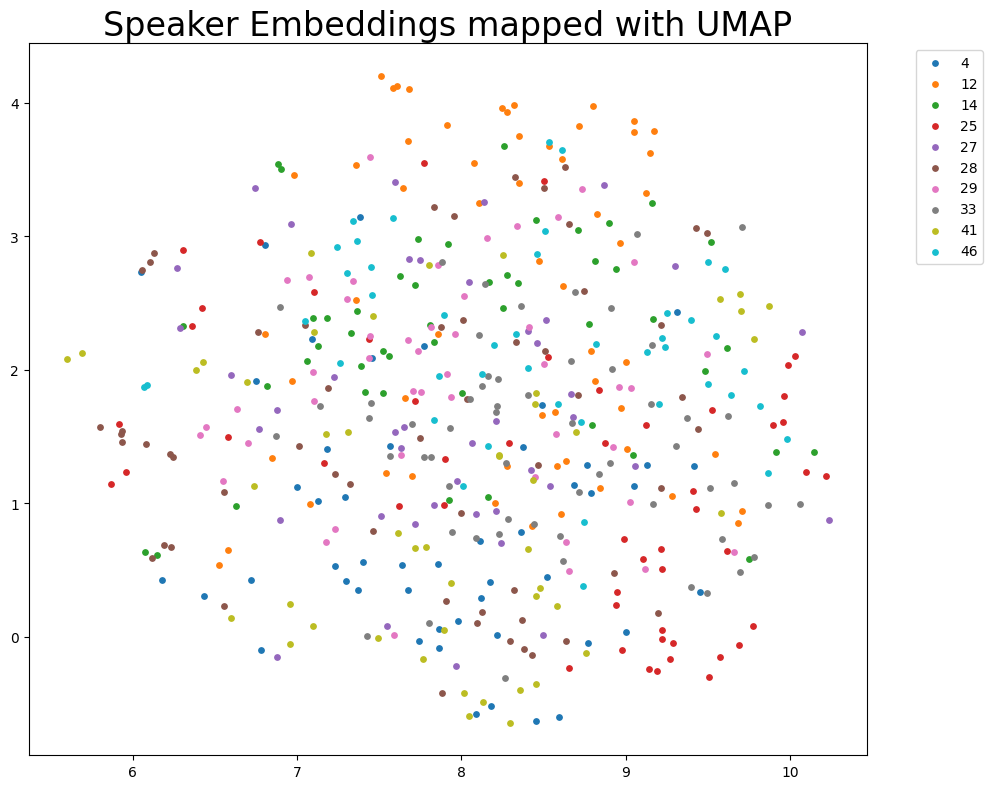

In [ ]:
visualize_with_umap(rand_embs, rand_labels)